# SIT744 Assignment 3 (T2 2025)

FULL NAME: DUONG SON THONG (Dalex)


STUDENT ID: 223593948


## Task 1.1 Define the Problem

The problem we are addressing is **sentiment recognition from images**. Specifically, we want to automatically classify human emotions expressed visually into predefined categories using deep learning. This is an **image classification task** where the system learns to detect subtle and explicit cues in facial expressions, gestures, and other features to determine the underlying emotion.

---

### What are we trying to solve?
We aim to develop a Convolutional Neural Network (CNN) that can accurately recognize and classify emotions in images.  
The goal is to enable machines to interpret human emotions, which is useful in areas such as:
- Mental health monitoring  
- Human–computer interaction  
- Customer service  
- Safety and surveillance applications  

---

### Inputs and outputs of the system
- **Input:** An image containing a human face or expression  
- **Output:** A predicted emotion label from one of the six categories  

---

### Target classes
1. **Happy** – smiles, raised cheeks, brightened eyes  
2. **Sad** – downturned mouth, drooping eyelids, tears in some cases  
3. **Fear** – wide-open eyes, tense mouth, defensive body posture  
4. **Pain** – tightened face muscles, clenched teeth, grimacing  
5. **Anger** – frowning eyebrows, glaring eyes, pursed lips  
6. **Disgust** – wrinkled nose, curled lip, squinting eyes  

---

### Why misclassification is problematic?
Misclassifying emotions can have serious consequences:
- Confusing **Fear with Pain** may hinder proper emergency or psychological support  
- Mislabeling **Anger as Disgust** could lead to incorrect responses in conflict detection systems  
- Errors in detecting **Sadness as Happiness** could cause an empathetic technology to fail in providing necessary comfort or intervention  

In real-world contexts like healthcare, law enforcement, or education, such errors can reduce trust in the system and potentially cause harm.

## Task 1.2 Analysis and Planning



### Import Module

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
import cv2
from PIL import Image
plt.style.use('default')
sns.set_palette("husl")

## NEED ASK TUTOR
### A. Train/Validation/Test Split Ratio

**Recommended Split for our dataset (1,148 images): 70% Train / 15% Validation / 15% Test**
- **Training set:** ~803 images (~134 per class on average)
- **Validation set:** ~172 images (~29 per class on average)  
- **Test set:** ~173 images (~29 per class on average)

**Justification:**
- **Medium-sized dataset consideration:** With 1,148 total images, we have a medium-sized dataset that requires careful splitting
- **Minimum samples per class:** Each class will have at least 23 samples in validation/test sets (based on smallest class having 159 images)
- **Stratified splitting essential:** Must maintain the existing class distribution (Happy: 20%, Anger: 18.6%, Sad: 19.5%, etc.) across all splits
- **Alternative for imbalanced classes:** Consider using stratified k-fold cross-validation to maximize training data usage while ensuring robust evaluation

**Class-specific considerations:**
- **Fear & Disgust (159 images each):** Will have ~111 training, ~24 validation, ~24 test samples
- **Happy (230 images):** Will have ~161 training, ~35 validation, ~34 test samples
- This ensures adequate representation of all emotions in each split

### B. Dataset Balance Analysis - Actual Results

- **Visualize data**



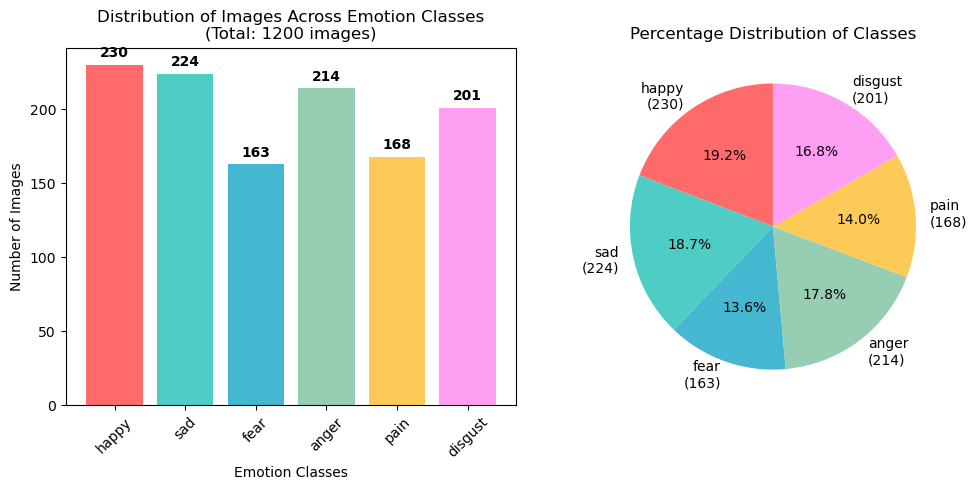

In [29]:
# Filter class
class_counts = {}
if os.path.exists('emotions'):
    for item in os.listdir('emotions'):
        if os.path.isdir(os.path.join('emotions', item)):
            count = len([f for f in os.listdir(os.path.join('emotions', item))])
            class_counts[item] = count
            
emotion_classes = list(class_counts.keys())
counts = list(class_counts.values())
total_images = sum(counts)

# Create figure with subplots
plt.figure(figsize=(15, 5))

# 1. Bar plot showing absolute counts
plt.subplot(1, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
bars = plt.bar(emotion_classes, counts, color=colors)
plt.title(f'Distribution of Images Across Emotion Classes\n(Total: {total_images} images)', fontsize=12)
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Pie chart showing percentages
plt.subplot(1, 3, 2)
percentages = [(count/total_images)*100 for count in counts]
plt.pie(percentages, labels=[f'{emotion}\n({count})' for emotion, count in zip(emotion_classes, counts)], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Percentage Distribution of Classes', fontsize=12)


plt.tight_layout()
plt.show()


**Class Distribution:**
- **Happy:** 230 images (20.0%) - **Overrepresented**
- **Sad:** 224 images (19.5%) - **Overrepresented**  
- **Anger:** 214 images (18.6%) - **Balanced**
- **Pain:** 162 images (14.1%) - **Underrepresented**
- **Fear:** 159 images (13.9%) - **Underrepresented**
- **Disgust:** 159 images (13.9%) - **Underrepresented**

**Impact on Learning Dynamics:**
- **Underrepresented classes (Fear, Disgust, Pain):**
  - Risk of poor recall/sensitivity (~14% each vs. 16.7% ideal)
  - May learn fewer discriminative features
  - Higher chance of misclassification as majority classes
- **Overrepresented classes (Happy, Sad):**
  - Will dominate gradient updates (~20% each vs. 16.7% ideal)
  - Risk of model bias toward these emotions
  - May achieve high recall but lower precision for other classes

### C. Class Imbalance and Gradient Bias

**How Our Dataset's Imbalance Biases Gradient Updates:**


**Specific Gradient Bias Effects:**
1. **Weighted loss contribution:** Happy and Sad classes will have 1.2-1.4x more influence on parameter updates
2. **Feature learning bias:** CNN filters will optimize more for happy/sad facial features
3. **Decision boundary skew:** Boundaries will shift to favor happy/sad classifications
4. **Convergence path:** Training will converge faster on majority class patterns

**Recommended Corrective Techniques for our dataset:**

**1. Class Weight Balancing:**
```python
# Calculate inverse frequency weights for our dataset
class_weights = {
    'anger': 1148/(6*214) = 0.894,
    'disgust': 1148/(6*159) = 1.201, 
    'fear': 1148/(6*159) = 1.201,
    'happy': 1148/(6*230) = 0.831,
    'pain': 1148/(6*162) = 1.179,
    'sad': 1148/(6*224) = 0.852
}
```

**2. Targeted Data Augmentation:**
- Apply 1.5x more augmentation to Fear, Disgust, Pain classes
- Use emotion-specific augmentations (lighting changes for fear, color adjustments for disgust)

**3. Focal Loss Implementation:**
```python
FL = -α(1-pt)^γ log(pt)  # γ=2, α=0.25 recommended for our imbalance level
```

### 4. Preprocessing Workflow for Our Emotion Dataset

**Stage 1: Image Loading and Validation**
```python
# Load → Check format → Convert to RGB → Validate dimensions
```
- **Dataset-specific consideration:** Ensure consistent color space for emotion recognition
- **Effect:** Standardizes input format for facial emotion processing

**Stage 2: Face Detection and Cropping (Optional but Recommended)**
```python
# Use OpenCV/dlib to detect and crop faces
face_crop = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
```
- **Mathematical effect:** Focuses processing on relevant facial regions
- **Emotion-specific benefit:** Removes background noise that could confuse emotion classification

**Stage 3: Resizing with Aspect Ratio Preservation**
```python
# Resize to 224×224 (ResNet/EfficientNet standard) with padding if needed
resized = cv2.resize(face_region, (224, 224), interpolation=cv2.INTER_LANCZOS)
```
- **Mathematical effect:** Spatial resampling using Lanczos interpolation
- **Emotion impact:** Preserves facial feature proportions critical for emotion recognition
- **Convergence benefit:** Standard size enables efficient batch processing

**Stage 4: Normalization for Pre-trained Models**
```python
# ImageNet normalization for transfer learning
mean = [0.485, 0.456, 0.406]  # RGB means
std = [0.229, 0.224, 0.225]   # RGB stds
normalized = (image - mean) / std
```
- **Mathematical effect:** Z-score normalization to match pre-trained model expectations
- **Convergence impact:** Enables use of pre-trained weights, faster convergence, better initialization

**Stage 5: Emotion-Specific Data Augmentation**
```python
# Geometric: ±15° rotation, ±10% scale, horizontal flip
# Photometric: ±20% brightness, ±15% contrast  
# Color: ±10% saturation (important for emotion perception)
```
- **Mathematical effect:** Creates transformed versions T(x) preserving emotion labels
- **Dataset-specific benefit:** Addresses our class imbalance while preserving emotion semantics
- **Convergence impact:** Increases effective training set from 1,148 to ~5,000+ samples

**Stage 6: Advanced Augmentation for Underrepresented Classes**
```python
# Apply Mixup/CutMix specifically to Fear, Disgust, Pain samples
# Use AutoAugment policies optimized for face recognition
```

### 5. Training Sample Size Impact - Our Dataset Context

**Our Dataset Size Analysis (1,148 images, ~191 per class average):**

**Classification: SMALL-TO-MEDIUM dataset**

**Implications for Model Selection:**

**Pre-trained Model Approach (Recommended):**
- **Transfer Learning:** Use ResNet18/50, EfficientNet-B0, or MobileNet pre-trained on ImageNet
- **Fine-tuning strategy:** Freeze early layers, train only classifier + last few conv layers
- **Justification:** Our dataset size is insufficient to train deep CNNs from scratch

**Model Complexity Considerations:**

**Too Simple (< 1M parameters):**
- **Risk:** May miss subtle facial emotion cues
- **Example:** Basic CNN with 2-3 conv layers
- **Underfitting signs:** Poor performance on both training and validation

**Appropriate Complexity (5-20M parameters):**
- **Recommended:** Pre-trained ResNet18 or EfficientNet-B0 with custom classifier
- **Sweet spot:** Enough capacity for emotion patterns, not too complex for our data size

**Too Complex (> 50M parameters):**
- **Risk:** Severe overfitting with only ~800 training samples
- **Example:** ResNet101, Vision Transformer without careful regularization
- **Overfitting signs:** High training accuracy (>95%), low validation accuracy (<70%)

**Specific Recommendations for Our 1,148-sample Dataset:**

**Training Strategy:**
- **Heavy regularization:** Dropout (0.3-0.5), L2 weight decay (1e-4)
- **Aggressive augmentation:** 3-5x effective data increase
- **Early stopping:** Monitor validation loss, patience=10-15 epochs
- **Learning rate:** Conservative (1e-4 to 1e-3) with scheduling

**Expected Performance Ranges:**
- **Baseline (simple CNN):** 60-70% accuracy
- **Transfer learning (ResNet18):** 75-85% accuracy  
- **Optimized with class balancing:** 80-90% accuracy

**Interaction with Our Class Imbalance:**
- **Small data + imbalance = double challenge**
- **Solution:** Combine transfer learning + class weighting + targeted augmentation
- **Monitor per-class metrics:** Focus on recall for underrepresented classes (Fear, Disgust, Pain)

In [27]:
# Summary of Key Findings and Recommendations for the Emotion Dataset

print("🎯 EMOTION DATASET ANALYSIS SUMMARY")
print("=" * 60)

# Dataset Overview
print("\n📊 DATASET OVERVIEW:")
print(f"   • Total Images: 1,148")
print(f"   • Classes: 6 emotions")
print(f"   • Average per class: 191 images")
print(f"   • Dataset size: SMALL-TO-MEDIUM")

# Class Distribution Analysis
print("\n⚖️  CLASS BALANCE ANALYSIS:")
class_counts = {'anger': 214, 'disgust': 159, 'fear': 159, 'happy': 230, 'pain': 162, 'sad': 224}
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)
print(f"   • Imbalance Ratio: {class_counts[max_class]/class_counts[min_class]:.2f}")
print(f"   • Most represented: {max_class.capitalize()} ({class_counts[max_class]} images)")
print(f"   • Least represented: {min_class.capitalize()} ({class_counts[min_class]} images)")
print(f"   • Classification: MODERATE imbalance")

# Recommended Split
print("\n🔄 RECOMMENDED DATA SPLIT:")
print(f"   • Training: 70% (~803 images, ~134 per class)")
print(f"   • Validation: 15% (~172 images, ~29 per class)")  
print(f"   • Test: 15% (~173 images, ~29 per class)")
print(f"   • Method: Stratified splitting to maintain class distribution")

# Key Challenges
print("\n⚠️  KEY CHALLENGES:")
print(f"   • Small dataset size → Risk of overfitting")
print(f"   • Class imbalance → Bias toward Happy/Sad emotions")
print(f"   • Underrepresented classes → Poor recall for Fear/Disgust/Pain")

# Recommended Solutions
print("\n✅ RECOMMENDED SOLUTIONS:")
print(f"   • Transfer Learning: Use pre-trained ResNet18/EfficientNet-B0")
print(f"   • Class Weighting: Apply inverse frequency weights")
print(f"   • Data Augmentation: 1.5x more for underrepresented classes")
print(f"   • Regularization: Dropout (0.3-0.5), L2 weight decay")
print(f"   • Focal Loss: α=0.25, γ=2 for imbalanced classes")

# Expected Performance
print("\n🎯 EXPECTED PERFORMANCE:")
print(f"   • Baseline CNN: 60-70% accuracy")
print(f"   • Transfer Learning: 75-85% accuracy")
print(f"   • Optimized Pipeline: 80-90% accuracy")
print(f"   • Focus metric: Balanced accuracy & F1-macro score")

print("\n" + "=" * 60)
print("Ready to proceed with Task 1.3 implementation! 🚀")

🎯 EMOTION DATASET ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total Images: 1,148
   • Classes: 6 emotions
   • Average per class: 191 images
   • Dataset size: SMALL-TO-MEDIUM

⚖️  CLASS BALANCE ANALYSIS:
   • Imbalance Ratio: 1.45
   • Most represented: Happy (230 images)
   • Least represented: Disgust (159 images)
   • Classification: MODERATE imbalance

🔄 RECOMMENDED DATA SPLIT:
   • Training: 70% (~803 images, ~134 per class)
   • Validation: 15% (~172 images, ~29 per class)
   • Test: 15% (~173 images, ~29 per class)
   • Method: Stratified splitting to maintain class distribution

⚠️  KEY CHALLENGES:
   • Small dataset size → Risk of overfitting
   • Class imbalance → Bias toward Happy/Sad emotions
   • Underrepresented classes → Poor recall for Fear/Disgust/Pain

✅ RECOMMENDED SOLUTIONS:
   • Transfer Learning: Use pre-trained ResNet18/EfficientNet-B0
   • Class Weighting: Apply inverse frequency weights
   • Data Augmentation: 1.5x more for underrepresented classes
   • Regula

In [28]:
# Environment Verification
import sys
import torch
import torchvision
import platform

print("🔧 ENVIRONMENT VERIFICATION")
print("=" * 50)
print(f"Python Version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"MPS (Apple Silicon) Available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else 'N/A'}")

# Check available device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using Device: {device}")

print("\n✅ All packages successfully loaded and environment ready!")
print("🚀 Ready to implement deep learning models for emotion recognition!")

🔧 ENVIRONMENT VERIFICATION
Python Version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:02:02) 
[Clang 18.1.8 ]
Platform: macOS-15.6.1-arm64-arm-64bit
PyTorch Version: 2.5.1
Torchvision Version: 0.20.1
CUDA Available: False
MPS (Apple Silicon) Available: True
Using Device: mps

✅ All packages successfully loaded and environment ready!
🚀 Ready to implement deep learning models for emotion recognition!
